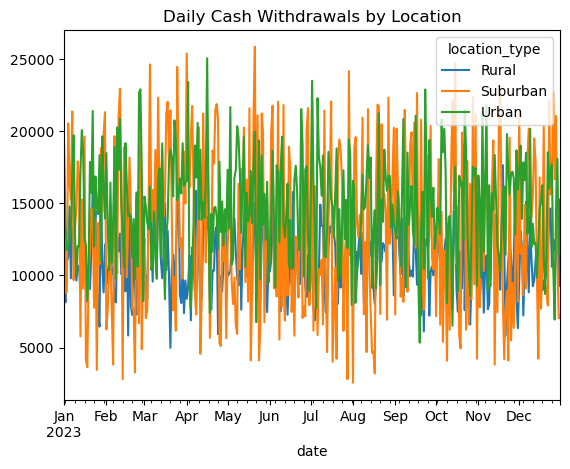

ValueError: All arrays must be of the same length

In [ ]:
# Exploratory Data Analysis by ATM Location and Type
# This script analyzes cash withdrawals from ATMs based on their location and type.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("atm_data.csv")
df['date'] = pd.to_datetime(df['date'])

# Plot cash withdrawals by location-type
df.groupby(['location_type', 'date'])['cash_withdrawn'].mean().unstack(0).plot()
plt.title("Daily Cash Withdrawals by Location")
plt.show()

# Plot cash withdrawals by ATM type
# Feature importance
import joblib
pipeline = joblib.load("cash_forecasting_model.pkl")

# Extract feature names from the model if available
if hasattr(model, 'feature_names_in_'):
    feature_columns = model.feature_names_in_
else:
    # Fallback to extracting feature names from the DataFrame `df`
    feature_columns = [col for col in df.columns if col not in ['cash_withdrawn', 'date', 'atm_id', 'location_type']]

# Ensure the model is a RandomForestRegressor
model = pipeline  # Since pipeline is already a RandomForestRegressor

# Create a DataFrame for feature importances
feature_importances = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Display the top 10 features
print(feature_importances.head(10))